# 01 - Data Exploration
## NewsBot Intelligence System 2.0 - Module A: Advanced Content Analysis Engine

This notebook loads the BBC News dataset (or the bundled offline sample), validates data quality, and explores the corpus before deeper NLP analysis in later notebooks.
> **Setup note:** This notebook uses the `src/` package from the project root.
> If running in Google Colab, first mount/clone the repo so `src/` is on the path,
> and place the Kaggle `BBC News Train.csv` in `data/raw/` for the real dataset
> (otherwise the bundled offline sample in `data/sample/` is used automatically).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from src.data_processing.data_loader import load_news_data, dataset_source
print("Dataset source:", dataset_source())


Dataset source: Bundled sample dataset (demo only): /home/claude/ITAI2373-NewsBot-Final/data/sample/sample_news.csv


## Load and validate the dataset

In [2]:
df = load_news_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (200, 4)


,article_id,title,content,category
0,1171,Atlas Energy announced layoffs affecting hundr...,Atlas Energy announced layoffs affecting hundr...,tech
1,1101,A parliamentary committee began an inquiry int...,A parliamentary committee began an inquiry int...,politics
2,1134,Fans celebrated as the visiting club clinched the,Fans celebrated as the visiting club clinched ...,sport
3,1051,A biopic about a chart-topping band is currently,A biopic about a chart-topping band is current...,entertainment
4,1027,Unemployment figures released this week showed...,Unemployment figures released this week showed...,business


In [3]:
from src.data_processing.data_validator import DataValidator

validator = DataValidator()
report = validator.validate(df)
print("Validation passed:", report["passed"])
print("Warnings:", report["warnings"])
print("Issues:", report["issues"])
report["stats"]

Validation passed: True
Warnings: []
Issues: []


{'category_counts': {'tech': 40,
  'politics': 40,
  'sport': 40,
  'entertainment': 40,
  'business': 40},
 'n_rows': 200,
 'n_categories': 5}

## Category distribution

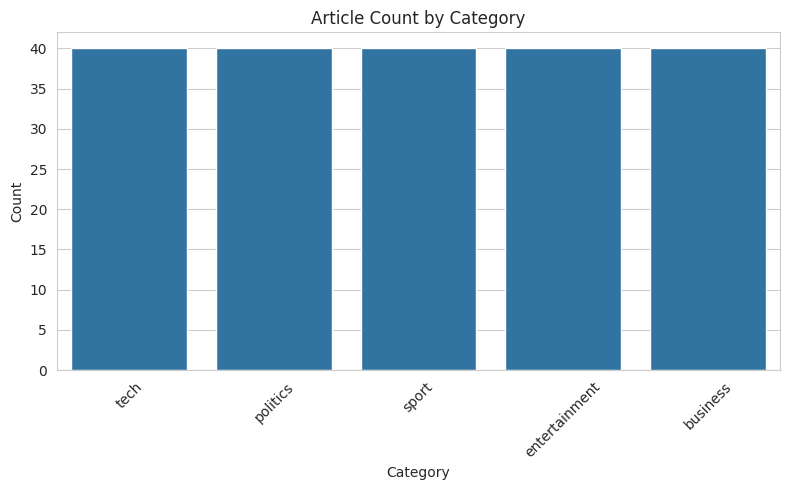

category
tech             40
politics         40
sport            40
entertainment    40
business         40
Name: count, dtype: int64

In [4]:
from src.utils.visualization import plot_category_distribution

fig, ax = plt.subplots(figsize=(8,5))
plot_category_distribution(df, ax=ax)
plt.tight_layout()
plt.show()

df['category'].value_counts()

## Article length distribution

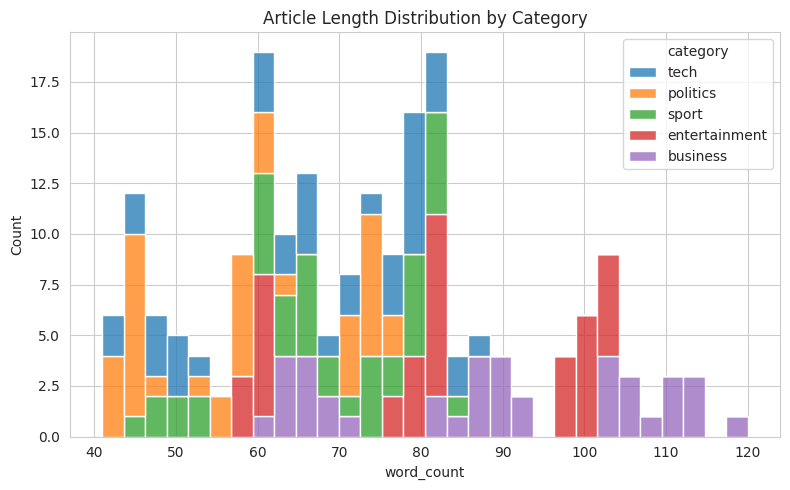

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
business,40.0,88.925,18.386711,61.0,69.00,89.0,105.00,120.0
entertainment,40.0,82.900,15.832132,58.0,73.25,82.0,99.00,104.0
politics,40.0,58.425,12.365974,41.0,45.75,58.0,72.00,77.0
sport,40.0,67.800,11.447091,45.0,60.75,67.5,78.00,84.0
tech,40.0,66.575,13.959442,41.0,51.75,68.0,78.25,87.0


In [5]:
df['word_count'] = df['content'].str.split().str.len()

fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data=df, x='word_count', hue='category', multiple='stack', bins=30, ax=ax)
ax.set_title('Article Length Distribution by Category')
plt.tight_layout()
plt.show()

df.groupby('category')['word_count'].describe()

## Preprocess the corpus
Apply the enhanced `TextPreprocessor` (cleaning, tokenization, stopword removal, lemmatization) used throughout the rest of the system.

In [6]:
from src.data_processing.text_preprocessor import TextPreprocessor

preprocessor = TextPreprocessor()
df = preprocessor.preprocess_dataframe(df, text_col='content', title_col='title')
df[['title', 'content_processed']].head(3)

,title,content_processed
0,Atlas Energy announced layoffs affecting hundr...,atlas energy announced layoff affecting hundre...
1,A parliamentary committee began an inquiry int...,parliamentary committee began inquiry tax refo...
2,Fans celebrated as the visiting club clinched the,fan celebrated visiting club clinched title ha...


In [7]:
# Save the processed dataset for reuse in later notebooks
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/articles_processed.csv', index=False)
print("Saved:", len(df), "processed articles")

Saved: 200 processed articles


## Key Takeaways
- The dataset is (roughly) balanced across the 5 BBC categories: business, entertainment, politics, sport, tech.
- No critical data-quality issues were found; minor duplicate/short-article warnings are handled by `DataValidator.clean()`.
- The processed corpus (`content_processed`) feeds directly into Notebook 02 (Classification) and 03 (Topic Modeling).